# Vieillissement cérébral et performances cognitives
## Projet personnel d'analyse de données
Le vieillissement normal s'accompagne de modifications cérébrales qui peuvent être étudiées à l'aide de mesures issues de l'imagerie médicale. Dans certaines pathologies neurodégénératives, notamment la maladie d'Alzheimer, ces modifications peuvent s'accompagner d'une diminution des performances cognitives. L'objectif de cette étude est d'explorer les relations entre âge, volume cérébral et fonctionnement cognitif à partir des données du jeu de données OASIS-1.

Le jeu de données OASIS-1 est une base de données de l'Université de Washington consacrée au vieillissement cérébral et à la maladie d'Alzheimer. Il comprend 416 sujets âgés de 18 à 96 ans. Parmi les personnes âgées de plus de 60 ans, une partie présente une maladie d'Alzheimer très légère à modérée.
Dans ce projet, nous utilisons uniquement le fichier de données démographiques et cliniques.

<u>Nous chercherons à répondre aux questions suivantes :</u>
1. L’âge est-il associé au volume cérébral ?
2. Le volume cérébral est-il associé aux performances cognitives ?
3. Les performances cognitives diffèrent-elles entre les participants sans démence et ceux présentant une démence ?

#### Variables utilisées
- **Age** : âge du participant ;
- **nWBV** : *Normalized Whole Brain Volume*, volume cérébral total normalisé ;
- **MMSE** : score au *Mini-Mental State Examination*, utilisé comme mesure globale du fonctionnement cognitif ;
- **CDR** : *Clinical Dementia Rating*, mesure de la sévérité de la démence ;

#### *Importation des bibliothèques*

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import micropip
await micropip.install("openpyxl")

#### *Chargement des données*

In [15]:
df = pd.read_excel("oasis.xlsx")
df.head()

,ID,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay
0,OAS1_0001_MR1,F,R,74,2.0,3.0,29.0,0.0,1344,0.743,1.306,NaN
1,OAS1_0002_MR1,F,R,55,4.0,1.0,29.0,0.0,1147,0.810,1.531,NaN
2,OAS1_0003_MR1,F,R,73,4.0,3.0,27.0,0.5,1454,0.708,1.207,NaN
3,OAS1_0004_MR1,M,R,28,NaN,NaN,NaN,NaN,1588,0.803,1.105,NaN
4,OAS1_0005_MR1,M,R,18,NaN,NaN,NaN,NaN,1737,0.848,1.010,NaN


#### *Statistiques descriptives*
Nous avons pour chaque variable utilisée le nombre de participants, la moyenne, l'écart type, le minimum, les quartiles, la médiane et le maximum.

In [16]:
variables = ["Age", "MMSE", "CDR", "nWBV"]
df[variables].describe()

,Age,MMSE,CDR,nWBV
count,436.000000,235.00000,235.000000,436.000000
mean,51.357798,27.06383,0.285106,0.791670
std,25.269862,3.69687,0.383405,0.059937
min,18.000000,14.00000,0.000000,0.644000
25%,23.000000,26.00000,0.000000,0.742750
50%,54.000000,29.00000,0.000000,0.809000
75%,74.000000,30.00000,0.500000,0.842000
max,96.000000,30.00000,2.000000,0.893000


In [18]:
# sert à identifier le nombre de valeurs manquantes pour chaque variable
df[variables].isna().sum()

Age       0
MMSE    201
CDR     201
nWBV      0
dtype: int64

On observe 201 valeurs manquantes pour les scores MMSE et CDR. <br>
En revanche, les variables Age et nWBV ne présentent aucune valeur manquante.

## 1. Âge et volume cérébral normalisé
#### *Problématique*
Notre question était : L'**âge** est-il associé au volume cérébral normalisé (**nWBV**) ? <br>
Ici, nous cherchons à connaître le lien entre les deux variables **âge** et **nWBV**. L'âge du participant est une variable numérique, ainsi que le volume cérébral total normalisé. <br>
Nous allons donc réaliser une corrélation de Bravais Pearson.

#### *Hypothèses*
- **H0** : pas de corrélation linéaire entre l'âge et le nWBV.
- **H1** : corrélation linéaire entre l'âge et le nWBV.

#### *Corrélation de Pearson*

In [19]:
age_nwbv = df[["Age", "nWBV"]].dropna()
r_age, p_age = stats.pearsonr(age_nwbv["Age"], age_nwbv["nWBV"])
print("r =", round(r_age, 3))
print("p-value =", p_age)

r = -0.874
p-value = 3.48852107338193e-138


#### *Nuage de points*

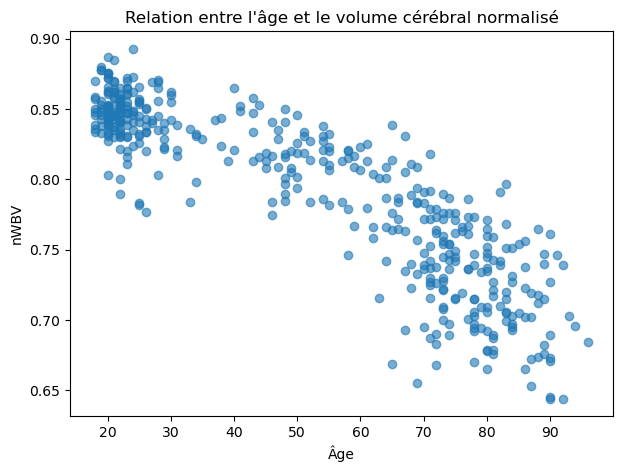

In [20]:
plt.figure(figsize=(7,5))
plt.scatter(age_nwbv["Age"], age_nwbv["nWBV"], alpha=0.6)
plt.xlabel("Âge")
plt.ylabel("nWBV")
plt.title("Relation entre l'âge et le volume cérébral normalisé")
plt.show()

#### *Interprétation*
Le coefficient de Pearson **r = -0,874** est très proche de -1 et négatif, ce qui indique une forte corrélation négative. <br>
La p-value est aussi très petite (p < 0,001), on peut donc rejeter H0.<br>
Pour le nuage de points, il nous montre visuellement que l'on voit une tendance descendante. <br>
Ainsi, plus l'âge des participants augmente, plus leur volume cérébral normalisé tend à diminuer. Cette corrélation étant statistiquement significative, nous rejetons l'hypothèse nulle.



## 2. Volume cérébral et performances cognitives
#### *Problématique*
Notre deuxième question était : Le volume cérébral (**nWBV**) est-il associé aux performances cognitives (**MMSE**) ? <br>
Ici, nous cherchons à connaître le lien entre les deux variables **nWBV** et **MMSE**. Les deux étant des variables numériques, nous allons donc réaliser une nouvelle corrélation de Bravais Pearson.

#### *Hypothèses*
- **H0** : pas de corrélation linéaire entre nWBV et MMSE.
- **H1** : corrélation linéaire entre nWBV et MMSE.

#### *Corrélation de Pearson*

In [21]:
volume_mmse = df[["nWBV", "MMSE"]].dropna() # supprime toutes les lignes où l’une des deux valeurs est manquante
r_mmse, p_mmse = stats.pearsonr(volume_mmse["nWBV"], volume_mmse["MMSE"])
print("r =", round(r_mmse, 3))
print("p-value =", p_mmse)

r = 0.47
p-value = 2.7216896451861543e-14


#### *Nuage de points*

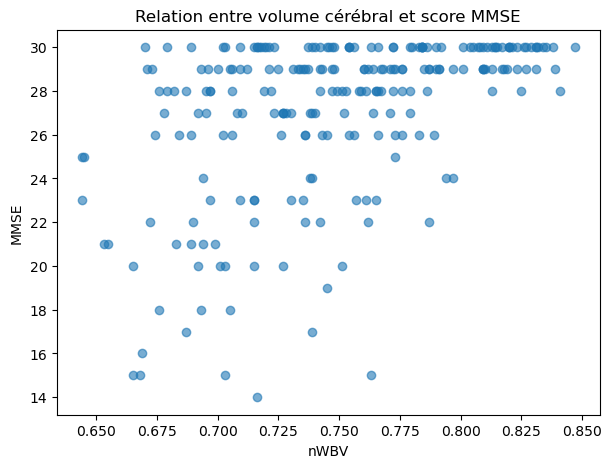

In [22]:
plt.figure(figsize=(7,5))
plt.scatter(volume_mmse["nWBV"], volume_mmse["MMSE"], alpha=0.6)
plt.xlabel("nWBV")
plt.ylabel("MMSE")
plt.title("Relation entre volume cérébral et score MMSE")
plt.show()

#### *Interprétation*
Le coefficient de Pearson **r = 0,47** est positif, ce qui indique une corrélation positive modérée. <br>
La p-value est très petite (p < 0,001), on peut donc rejeter H0. <br>
Pour le nuage de points, on observe une tendance générale selon laquelle les scores MMSE sont plus élevés lorsque le nWBV augmente. <br>
Ainsi, plus le volume cérébral normalisé des participants est élevé, plus leur score MMSE tend à être élevé. Cette corrélation étant statistiquement significative, nous rejetons l'hypothèse nulle.

## 3. Comparaison du MMSE selon le CDR
#### *Problématique*
Notre question était : Le score **MMSE** diffère-t-il entre les participants n'ayant pas de démence (**CDR = 0**) et ceux qui en ont une (**CDR > 0**) ? <br>
Ici, nous cherchons à comparer deux moyennes : la moyenne au MMSE pour les participants ayant une démence avec la moyenne au MMSE pour les participants sans démence.<br>
Le score MMSE est la variable dépendante numérique.<br>
Pour répondre à notre question, ici le CDR est la variable indépendante catégorielle inter-sujet à deux modalités  : avec démence (> 0) / sans démence (= 0).<br>
On utilise donc un test t de Student pour échantillons indépendants.

#### *Hypothèses*
- **H0** : les moyennes de MMSE sont égales.
- **H1** : les moyennes de MMSE sont différentes.

#### *Création des groupes et statistiques descriptives*

In [23]:
# supprime aussi toutes les lignes où l’une des deux valeurs est manquante
groupe_cdr0 = df.loc[df["CDR"] == 0, "MMSE"].dropna()
groupe_cdr_sup0 = df.loc[df["CDR"] > 0, "MMSE"].dropna()

# statistiques descriptives
print("nombre CDR = 0 :", len(groupe_cdr0))
print("nombre CDR > 0 :", len(groupe_cdr_sup0))
print("moyenne CDR = 0 :", round(groupe_cdr0.mean(), 2))
print("moyenne CDR > 0 :", round(groupe_cdr_sup0.mean(), 2))
print("écart-type CDR = 0 :", round(groupe_cdr0.std(), 2))
print("écart-type CDR > 0 :", round(groupe_cdr_sup0.std(), 2))

nombre CDR = 0 : 135
nombre CDR > 0 : 100
moyenne CDR = 0 : 29.1
moyenne CDR > 0 : 24.32
écart-type CDR = 0 : 1.13
écart-type CDR > 0 : 4.17


#### *Homogénéité des variances*
Les écarts-types des deux groupes sont différents : 1,13 pour le groupe CDR = 0 et 4,17 pour le groupe CDR > 0.<br>
Les variances ne semblent donc pas homogènes. Nous utiliserons ainsi le test t de Student avec correction de Welch.


#### *Test t de Student avec correction de Welch*

In [24]:
t_stat, p_welch = stats.ttest_ind(
    groupe_cdr0,
    groupe_cdr_sup0,
    equal_var=False
)

print("t =", round(t_stat, 3))
print("p-value =", p_welch)

t = 11.168
p-value = 8.342045891831942e-20


#### *Graphique en barre*

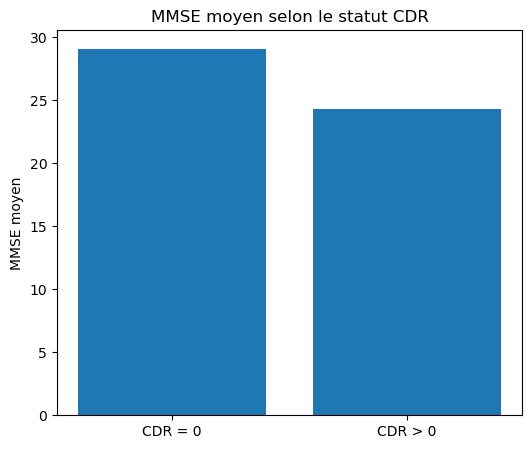

In [25]:
plt.figure(figsize=(6,5))
plt.bar(["CDR = 0", "CDR > 0"], [groupe_cdr0.mean(), groupe_cdr_sup0.mean()])
plt.ylabel("MMSE moyen")
plt.title("MMSE moyen selon le statut CDR")
plt.show()

#### *Interprétation*
Le test t de Student avec correction de Welch donne **t = 11,168** avec une p-value très petite (p < 0,001).<br>
On peut donc rejeter H0 : les performances cognitives diffèrent significativement entre les deux groupes. <br>
Les participants avec un CDR = 0 ont un score MMSE moyen de 29,10, contre 24,32 pour les participants avec un CDR > 0.<br>
Le graphique montre également que le score MMSE moyen est plus élevé chez les participants avec un CDR = 0 que chez ceux avec un CDR > 0, ce qui va dans le même sens que les résultats du test statistique.<br>
Ainsi, les participants sans démence présentent en moyenne de meilleures performances cognitives que les participants présentant une démence.<br>
La différence étant statistiquement significative, nous rejetons l'hypothèse nulle.

### Matrice de corrélations entre les quatre variables

In [26]:
correlations = df[variables].corr(method="pearson")
correlations.round(2)

,Age,MMSE,CDR,nWBV
Age,1.00,-0.25,0.30,-0.87
MMSE,-0.25,1.00,-0.75,0.47
CDR,0.30,-0.75,1.00,-0.50
nWBV,-0.87,0.47,-0.50,1.00


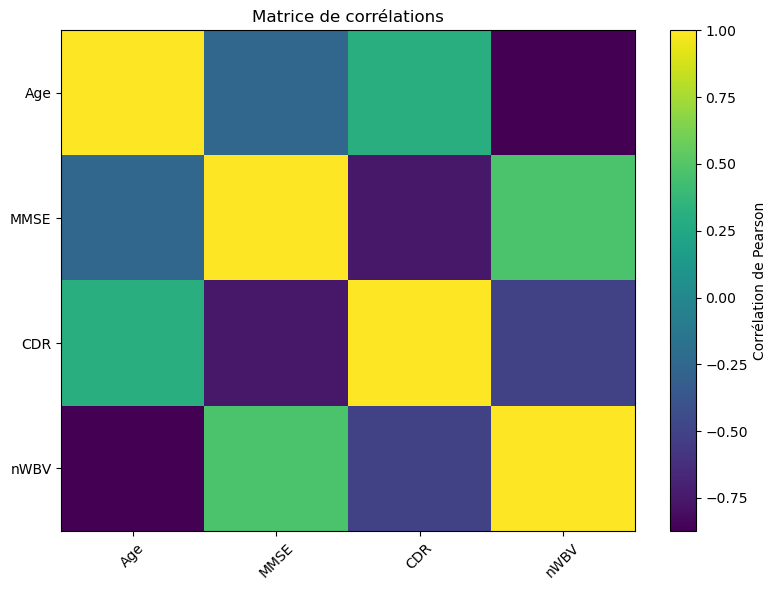

In [27]:
plt.figure(figsize=(8,6))
plt.imshow(correlations, aspect="auto")
plt.xticks(range(len(variables)), variables, rotation=45)
plt.yticks(range(len(variables)), variables)
plt.colorbar(label="Corrélation de Pearson")
plt.title("Matrice de corrélations")
plt.tight_layout()
plt.show()

#### *Interprétation de la matrice*
La matrice de corrélations permet d'observer les relations entre les quatre variables étudiées.<br>
On retrouve notamment une forte corrélation négative entre l'âge et le nWBV (r = -0,87), ainsi qu'une corrélation positive modérée entre le nWBV et le MMSE (r = 0,47), ce qui correspond aux résultats obtenus précédemment.<br>
On observe également une forte corrélation négative entre le CDR et le MMSE (r = -0,75) : plus le score CDR est élevé, plus le score MMSE tend à être faible. Le CDR est également négativement associé au nWBV (r = -0,50).<br>
Enfin, les relations entre l'âge et le MMSE (r = -0,25) et entre l'âge et le CDR (r = 0,30) sont plus faibles.

## Discussion et limites
Les résultats obtenus mettent en évidence plusieurs relations entre l'âge, le volume cérébral et les performances cognitives des participants.<br>
- Tout d'abord, nous avons observé une forte corrélation négative entre l'âge et le volume cérébral normalisé. Ainsi, plus l'âge des participants augmente, plus leur volume cérébral tend à diminuer.
- Nous avons également observé une corrélation positive modérée entre le volume cérébral et les performances cognitives. Les participants ayant un volume cérébral normalisé plus élevé tendent donc à obtenir de meilleurs scores au MMSE.
- Enfin, les participants avec un CDR = 0 présentent un score MMSE moyen plus élevé (29,10) que les participants avec un CDR > 0 (24,32). Le test t de Student avec correction de Welch montre que cette différence est statistiquement significative.<br>
Dans l'ensemble, ces résultats montrent donc des associations entre le vieillissement, le volume cérébral et les performances cognitives dans l'échantillon étudié.

Cette étude présente cependant plusieurs limites : <br>
- il s'agit d'une étude transversale : les participants sont observés à un moment donné et ne sont pas suivis dans le temps. Les résultats permettent donc d'identifier des associations entre les variables, mais pas de montrer de causalité.
- les variables MMSE et CDR comportent 201 valeurs manquantes, ce qui réduit le nombre de participants disponibles pour certaines analyses.
- le MMSE est un score global des performances cognitives, il ne permet pas d'étudier séparément les différentes fonctions cognitives qui pourraient être affectées.
- d'autres variables pourraient intervenir dans les relations observées et ne sont pas prises en compte dans cette étude, les résultats doivent donc être interprétés avec prudence.

## Conclusion
Cette étude avait pour objectif d'explorer les relations entre l'âge, le volume cérébral et les performances cognitives à partir des données OASIS-1.<br>
Les analyses montrent que l'augmentation de l'âge est fortement associée à une diminution du volume cérébral normalisé. Un volume cérébral plus élevé est également associé à de meilleures performances cognitives, et les participants présentant un CDR supérieur à 0 obtiennent en moyenne des scores MMSE plus faibles que les participants avec un CDR égal à 0.<br>
Ces résultats mettent ainsi en évidence des associations entre vieillissement, caractéristiques cérébrales et fonctionnement cognitif, en tenant compte des limites de l'étude.

#### *Source*
Marcus, D. S., Wang, T. H., Parker, J., Csernansky, J. G., Morris, J. C., & Buckner, R. L. (2007). *Open Access Series of Imaging Studies (OASIS): Cross-sectional MRI Data in Young, Middle Aged, Nondemented, and Demented Older Adults.* Journal of Cognitive Neuroscience, 19(9), 1498–1507.<br>
Projet OASIS — Washington University in St. Louis.